# Complete Exploratory Data Analysis (EDA) on Text Data | Text Data Visualization

Dataset: https://raw.githubusercontent.com/AFAgarap/ecommerce-reviews-analysis/refs/heads/master/Womens%20Clothing%20E-Commerce%20Reviews.csv

Women's E-Commerce Clothing Reviews
- `Clothing ID`: Integer Categorical variable that refers to the specific piece being reviewed.
- `Age`: Positive Integer variable of the reviewers age.
- `Title`: String variable for the title of the review.
- `Review Text`: String variable for the review body.
- `Rating`: Positive Ordinal Integer variable for the product score granted by the customer from 1 Worst, to 5 Best.
- `Recommended IND`: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.
- `Positive Feedback Count`: Positive Integer documenting the number of other customers who found this review positive.
- `Division Name`: Categorical name of the product high level division.
- `Department Name`: Categorical name of the product department name.
- `Class Name`: Categorical name of the product class name.

Installing Libraries

In [6]:
#!pip install cufflinks
#!pip install plotly
#!pip install textblob

Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly as py
from plotly.offline import iplot
import warnings

Setting Up Visualization Tools

In [12]:
%matplotlib inline
warnings.filterwarnings('ignore')
cf.go_offline()
py.offline.init_notebook_mode(connected=True)

## LOADING AND DISPLAYING DATA

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/AFAgarap/ecommerce-reviews-analysis/refs/heads/master/Womens%20Clothing%20E-Commerce%20Reviews.csv', index_col=0)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Data Information

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


Dropping Columns

In [21]:
df.drop(labels=['Title', 'Clothing ID'], axis=1, inplace=True)
df.head()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,34,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Checking for Missing Values

In [24]:
df.isnull().sum()

Age                          0
Review Text                845
Rating                       0
Recommended IND              0
Positive Feedback Count      0
Division Name               14
Department Name             14
Class Name                  14
dtype: int64

Handling Missing Values

In [27]:
df.dropna(subset=['Review Text','Division Name'], inplace=True)
df.isnull().sum()

Age                        0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

## EXPLORING REVIEW TEXT DATA

Displaying Review Text

In [31]:
df['Review Text'].head()

0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it's sooo pretty.  i happene...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it's fun, fl...
4    This shirt is very flattering to all due to th...
Name: Review Text, dtype: object

Review Text to List

In [34]:
df['Review Text'][:5].tolist()

['Absolutely wonderful - silky and sexy and comfortable',
 'Love this dress!  it\'s sooo pretty.  i happened to find it in a store, and i\'m glad i did bc i never would have ordered it online bc it\'s petite.  i bought a petite and am 5\'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.',
 'I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c',
 "I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments

Joining Review Texts

In [38]:
' '.join(df['Review Text'].tolist())[:1000]

'Absolutely wonderful - silky and sexy and comfortable Love this dress!  it\'s sooo pretty.  i happened to find it in a store, and i\'m glad i did bc i never would have ordered it online bc it\'s petite.  i bought a petite and am 5\'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite. I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c I love, love, love this jumpsuit. it\'s fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments! This shirt

## TEXT CLEANING

Contractions

In [45]:
contractions = {
  "ain't": "am not",
  "aren't": "are not",
  "bak": "back",
  "brng": "bring",
  "can't": "cannot",
  "can't've": "cannot have",
  "'cause": "because",
  "could've": "could have",
  "couldn't": "could not",
  "couldn't've": "could not have",
  "didn't": "did not",
  "didn't": "did not",
  "dis": "this",
  "don't": "do not",
  "hadn't": "had not",
  "hadn't've": "had not have",
  "hasn't": "has not",
  "haven't": "have not",
  "he'd": "he would",
  "he'd've": "he would have",
  "he'll": "he will",
  "he'll've": "he will have",
  "he's": "he is",
  "how'd": "how did",
  "how'd'y": "how do you",
  "how'll": "how will",
  "how's": "how is",
  "I'd": "I would",
  "I'd've": "I would have",
  "I'll": "I will",
  "I'll've": "I will have",
  "I'm": "I am",
  "I've": "I have",
  "i'm": "i am",
  "isn't": "is not",
  "it'd": "it had",
  "it'd've": "it would have",
  "it'll": "it will",
  "it'll've": "it will have",
  "it's": "it is",
  "let's": "let us",
  "ma'am": "madam",
  "mayn't": "may not",
  "might've": "might have",
  "mightn't": "might not",
  "mightn't've": "might not have",
  "must've": "must have",
  "mustn't": "must not",
  "mustn't've": "must not have",
  "needn't": "need not",
  " n ": "end",
  "needn't've": "need not have",
  "o'clock": "of the clock",
  "oughtn't": "ought not",
  "oughtn't've": "ought not have",
  "shan't": "shall not",
  "sha'n't": "shall not",
  "shan't've": "shall not have",
  "she'd": "she would",
  "she'd've": "she would have",
  "she'll": "she will",
  "she'll've": "she will have",
  "she's": "she is",
  "should've": "should have",
  "shouldn't": "should not",
  "shouldn't've": "should not have",
  "so've": "so have",
  "so's": "so is",
  "that'd": "that would",
  "that'd've": "that would have",
  "that's": "that is",
  "there'd": "there had",
  "there'd've": "there would have",
  "there's": "there is",
  "they'd": "they would",
  "they'd've": "they would have",
  "they'll": "they will",
  "they'll've": "they will have",
  "they're": "they are",
  "they've": "they have",
  "to've": "to have",
  " u ": "you",
  " ur ": "your",
  "wasn't": "was not",
  "we'd": "we had",
  "we'd've": "we would have",
  "we'll": "we will",
  "we'll've": "we will have",
  "we're": "we are",
  "we've": "we have",
  "weren't": "were not",
  "what'll": "what will",
  "what'll've": "what will have",
  "what're": "what are",
  "what's": "what is",
  "what've": "what have",
  "when's": "when is",
  "when've": "when have",
  "where'd": "where did",
  "where's": "where is",
  "where've": "where have",
  "who'll": "who will",
  "who'll've": "who will have",
  "who's": "who is",
  "who've": "who have",
  "why's": "why is",
  "why've": "why have",
  "will've": "will have",
  "won't": "will not",
  "won't've": "will not have",
  "would've": "would have",
  "wouldn't": "would not",
  "wouldn't've": "would not have",
  "y'all": "you all",
  "y'alls": "you alls",
  "y'all'd": "you all would",
  "y'all'd've": "you all would have",
  "y'all're": "you all are",
  "y'all've": "you all have",
  "you'd": "you had",
  "you'd've": "you would have",
  "you'll": "you you will",
  "you'll've": "you you will have",
  "you're": "you are",
  "you've": "you have"
}

Defining Contraction Expansion Function

In [48]:
def con_to_exp(x):
    if type(x) is str:
      x = x.replace('\\', '')
      for key, value in contractions.items():
          x = x.replace(key, value)
      return x
    else:
      return x
x = "i don't know what you want, i'm 5'8\""

In [50]:
con_to_exp(x)

'i do not know what you want, i am 5\'8"'

Applying Contraction Expansion (Timing)

In [55]:
%%timeit
df['Review Text'] = df['Review Text'].apply(lambda x: con_to_exp(x))

682 ms ± 5.28 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [57]:
df.head()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [59]:
' '.join(df['Review Text'].tolist())[:1000]

'Absolutely wonderful - silky and sexy and comfortable Love this dress!  it is sooo pretty.  i happened to find it in a store, and i am glad i did bc i never would have ordered it online bc it is petite.  i bought a petite and am 5\'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite. I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c I love, love, love this jumpsuit. it is fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments! This shirt

## FEATURE ENGINEERING

In [62]:
from textblob import TextBlob

In [64]:
df.head()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


#### Calculating Sentiment Polarity

In [67]:
df['polarity'] = df['Review Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df.head()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0.073675
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants,0.550000
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.512891


#### Calculating Review Length

In [70]:
df['review_len'] = df['Review Text'].apply(lambda x: len(x)) 
df.head() 

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583,306
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0.073675,500
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants,0.550000,125
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.512891,192


#### Calculating Word Count

In [73]:
df['word_count'] = df['Review Text'].apply(lambda x: len(x.split())) 
df.head() 

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len,word_count
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53,8
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583,306,65
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0.073675,500,98
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants,0.550000,125,23
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.512891,192,36


#### Calculating Average Word Length 

In [76]:
def get_avg_word_len(x):
  words = x.split()
  word_len = 0
  for word in words:
    word_len += len(word)
  return word_len/len(words) 

In [78]:
df['avg_word_len'] = df['Review Text'].apply(lambda x: get_avg_word_len(x)) 
df.head() 

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len,word_count,avg_word_len
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53,8,5.750000
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583,306,65,3.646154
2,60,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0.073675,500,98,4.112245
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants,0.550000,125,23,4.478261
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.512891,192,36,4.361111


## DISTRIBUTION OF SENTIMENT POLARITY

In [81]:
#import cufflinks as cf
#import plotly as py
#from plotly.offline import iplot

#%matplotlib inline
#warnings.filterwarnings('ignore')
#cf.go_offline()
#py.offline.init_notebook_mode(connected=True) 

Polarity Distribution Visualization

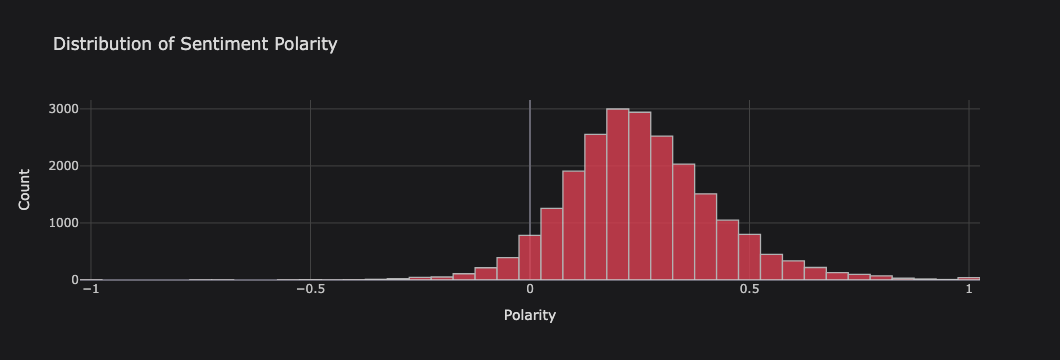

In [89]:
df['polarity'].iplot(kind='hist', bins=50, colors='red', xTitle='Polarity', yTitle='Count', title='Distribution of Sentiment Polarity')

## DISTRIBUTION OF REVIEWS RATING AND REVIEWERS AGE

Polarity Distribution Visualization

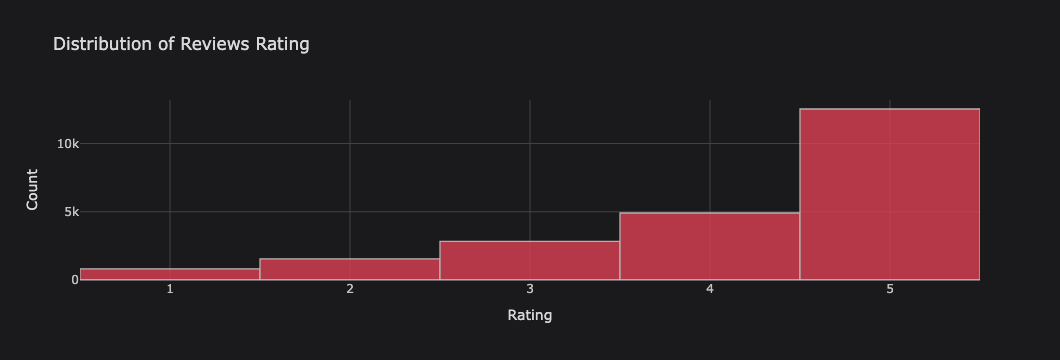

In [93]:
df['Rating'].iplot(
    kind='hist', 
    bins=5, 
    colors='red', 
    xTitle='Rating', 
    yTitle='Count', 
    title='Distribution of Reviews Rating')

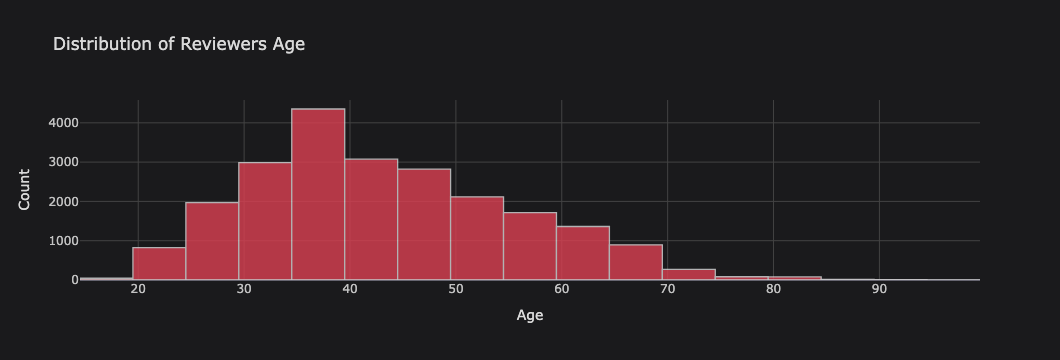

In [99]:
df['Age'].iplot(
    kind='hist', 
    bins=40, 
    colors='red',
    xTitle='Age', 
    yTitle='Count', 
    title='Distribution of Reviewers Age')

## DISTRIBUTION OF REVIEW TEXT LENGTH AND WORD LENGTH

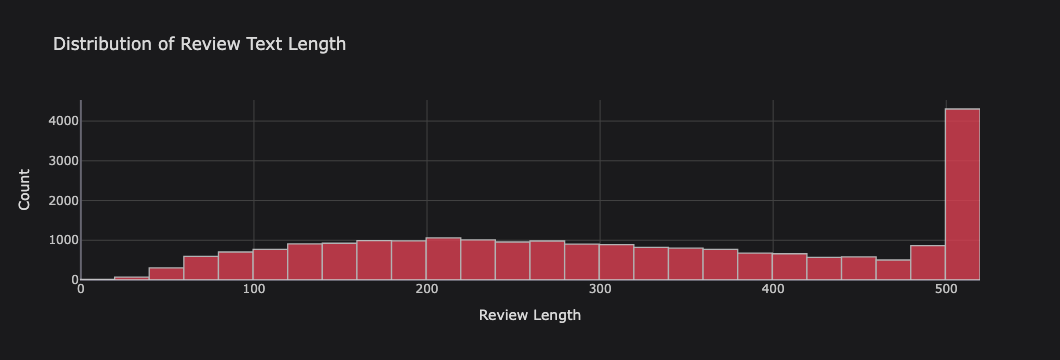

In [103]:
df['review_len'].iplot(
    kind='hist', 
    bins=50, 
    colors='red', 
    xTitle='Review Length', 
    yTitle='Count', 
    title='Distribution of Review Text Length')

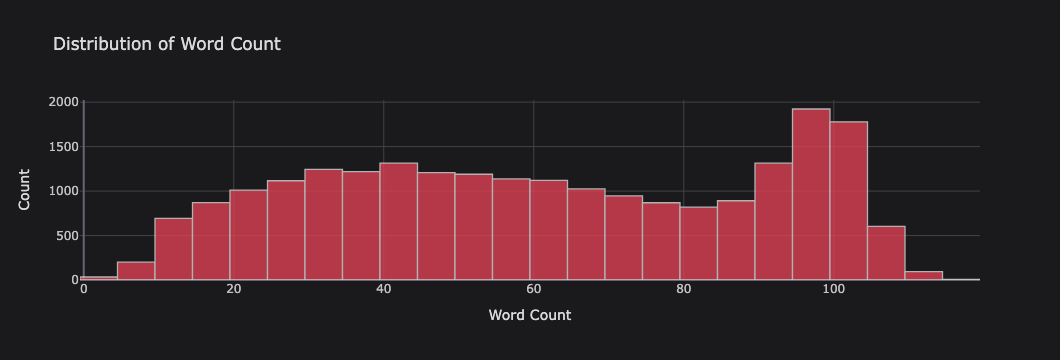

In [105]:
df['word_count'].iplot(
    kind='hist', 
    bins=50, 
    colors='red', 
    xTitle='Word Count', 
    yTitle='Count', 
    title='Distribution of Word Count')

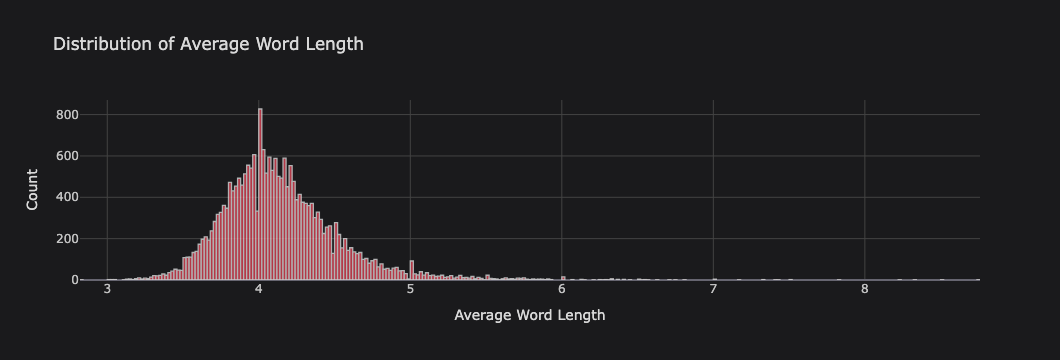

In [113]:
df['avg_word_len'].iplot(
    kind='hist', 
    bins=500, 
    colors='red', 
    xTitle='Average Word Length', 
    yTitle='Count', 
    title='Distribution of Average Word Length')

## DISTRIBUTION OF DEPARTMENT, DIVISION AND CLASS

In [119]:
df.head(1)

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len,word_count,avg_word_len
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53,8,5.75


In [121]:
df['Department Name'].value_counts()

Department Name
Tops        10048
Dresses      6145
Bottoms      3662
Intimate     1653
Jackets      1002
Trend         118
Name: count, dtype: int64

In [123]:
df.groupby('Department Name').count()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Class Name,polarity,review_len,word_count,avg_word_len
Department Name,,,,,,,,,,,
Bottoms,3662,3662,3662,3662,3662,3662,3662,3662,3662,3662,3662
Dresses,6145,6145,6145,6145,6145,6145,6145,6145,6145,6145,6145
Intimate,1653,1653,1653,1653,1653,1653,1653,1653,1653,1653,1653
Jackets,1002,1002,1002,1002,1002,1002,1002,1002,1002,1002,1002
Tops,10048,10048,10048,10048,10048,10048,10048,10048,10048,10048,10048
Trend,118,118,118,118,118,118,118,118,118,118,118


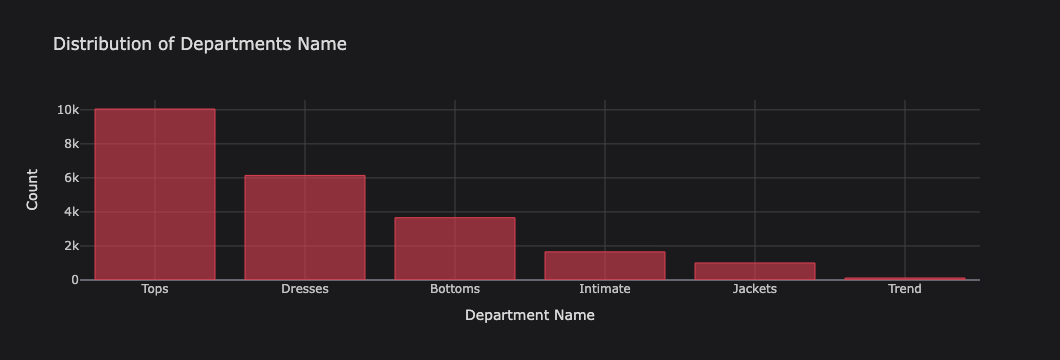

In [129]:
df['Department Name'].value_counts().iplot(
    kind='bar', 
    colors='red', 
    xTitle='Department Name', 
    yTitle='Count', 
    title='Distribution of Departments Name')

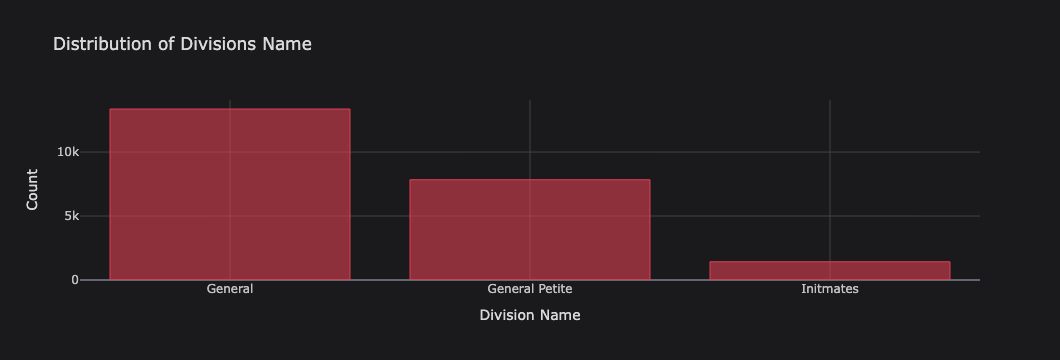

In [131]:
df['Division Name'].value_counts().iplot(
    kind='bar', 
    colors='red', 
    xTitle='Division Name', 
    yTitle='Count', 
    title='Distribution of Divisions Name')

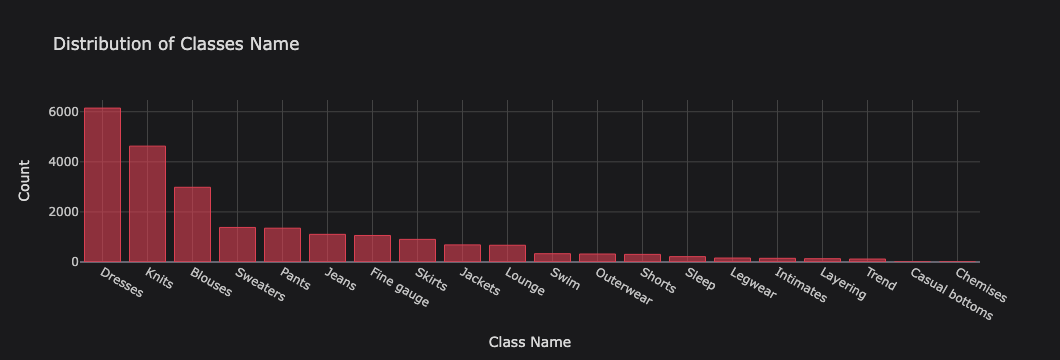

In [133]:
df['Class Name'].value_counts().iplot(
    kind='bar', 
    colors='red', 
    xTitle='Class Name', 
    yTitle='Count', 
    title='Distribution of Classes Name')

## DISTRIBUTION OF `UNIGRAM`, `BIGRAM` AND `TRIGRAM` 

In [138]:
from sklearn.feature_extraction.text import CountVectorizer

#### `N-gram` Example

In [136]:
x = "this is a test example"

#unigram = this, is, a, test, example
#bigram  = this is, is a, a test, test example
#trigram = this is a, is a test, a test example

## `Unigram`

In [148]:
x = ['this is the list list this this']

vec = CountVectorizer().fit(x)
bow = vec.transform(x)
sum_words = bow.sum(axis=0)
vec.vocabulary_.items()

dict_items([('this', 3), ('is', 0), ('the', 2), ('list', 1)])

#### Analyzing `Word Frequencies` 

In [150]:
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
print(words_freq[0])
print(words_freq[:1])
print(words_freq[:2])

('this', 3)
[('this', 3)]
[('this', 3), ('list', 2)]


#### Defining and Applying Top Words Function

In [164]:
def get_top_words(x, n):
  vec = CountVectorizer().fit(x)
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n]

In [166]:
get_top_words(x, 3)

[('this', 3), ('list', 2), ('is', 1)]

In [168]:
words = get_top_words(df['Review Text'], 20)
words

[('the', 76157),
 ('it', 49273),
 ('and', 48992),
 ('is', 38141),
 ('this', 25758),
 ('to', 24577),
 ('in', 20721),
 ('but', 16549),
 ('not', 16032),
 ('on', 15325),
 ('for', 13994),
 ('of', 13428),
 ('was', 12923),
 ('with', 12797),
 ('so', 12016),
 ('am', 11625),
 ('my', 11027),
 ('dress', 10567),
 ('that', 10009),
 ('love', 8944)]

#### Unigram Distribution Visualization

In [184]:
df1 = pd.DataFrame(words, columns=['Unigram', 'Frequency'])
df1.head()

,Unigram,Frequency
0,the,76157
1,it,49273
2,and,48992
3,is,38141
4,this,25758


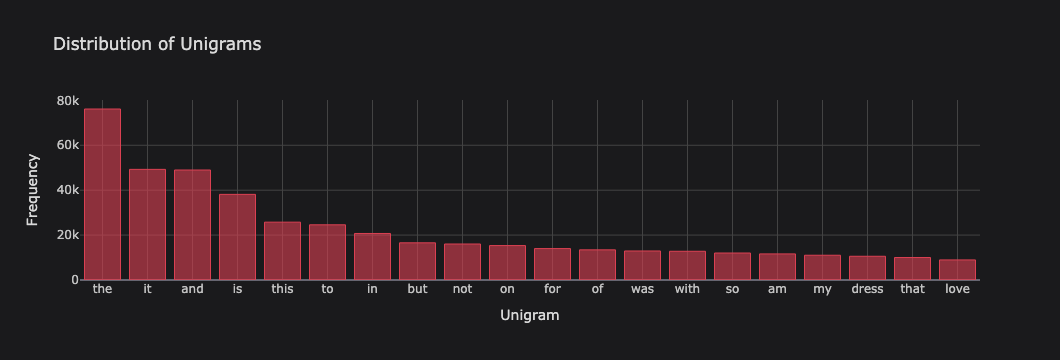

In [186]:
df1 = df1.set_index('Unigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Unigram', 
    yTitle='Frequency', 
    title='Distribution of Unigrams')

## Bigram

In [196]:
x = ['this is the list list this this']

vec = CountVectorizer(ngram_range=(2, 2)).fit(x) #addet -> ngram_range=(2, 2)
bow = vec.transform(x)
sum_words = bow.sum(axis=0)
vec.vocabulary_.items()

dict_items([('this is', 4), ('is the', 0), ('the list', 3), ('list list', 1), ('list this', 2), ('this this', 5)])

In [198]:
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
print(words_freq[0])
print(words_freq[:1])
print(words_freq[:2])

('this is', 1)
[('this is', 1)]
[('this is', 1), ('is the', 1)]


In [200]:
def get_top_words(x, n):
  vec = CountVectorizer(ngram_range=(2, 2)).fit(x) #addet -> ngram_range=(2, 2)
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n]

In [202]:
get_top_words(x, 3)

[('this is', 1), ('is the', 1), ('the list', 1)]

In [204]:
words = get_top_words(df['Review Text'], 20)
words

[('it is', 12525),
 ('in the', 7169),
 ('and the', 5611),
 ('this dress', 4758),
 ('on the', 4337),
 ('of the', 3933),
 ('and it', 3723),
 ('it was', 3287),
 ('this top', 2939),
 ('this is', 2772),
 ('is very', 2729),
 ('the fabric', 2654),
 ('love the', 2641),
 ('did not', 2486),
 ('love this', 2331),
 ('to wear', 2266),
 ('but it', 2196),
 ('the dress', 2180),
 ('is not', 2135),
 ('do not', 2115)]

In [206]:
df1 = pd.DataFrame(words, columns=['Bigram', 'Frequency'])
df1.head()

,Bigram,Frequency
0,it is,12525
1,in the,7169
2,and the,5611
3,this dress,4758
4,on the,4337


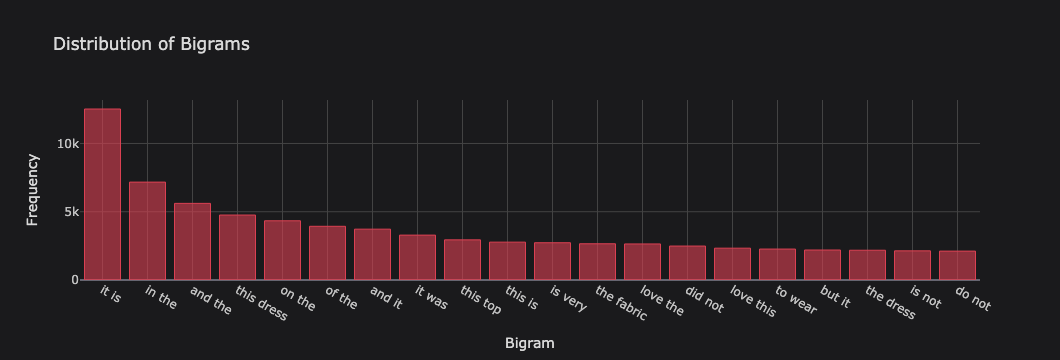

In [208]:
df1 = df1.set_index('Bigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Bigram', 
    yTitle='Frequency', 
    title='Distribution of Bigrams')

## Trigram

In [211]:
x = ['this is the list list this this']

vec = CountVectorizer(ngram_range=(3, 3)).fit(x) #addet -> ngram_range=(3, 3)
bow = vec.transform(x)
sum_words = bow.sum(axis=0)
vec.vocabulary_.items()

dict_items([('this is the', 4), ('is the list', 0), ('the list list', 3), ('list list this', 1), ('list this this', 2)])

In [213]:
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
print(words_freq[0])
print(words_freq[:1])
print(words_freq[:2])

('this is the', 1)
[('this is the', 1)]
[('this is the', 1), ('is the list', 1)]


In [215]:
def get_top_words(x, n):
  vec = CountVectorizer(ngram_range=(3, 3)).fit(x) #addet -> ngram_range=(3, 3)
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n] 

In [217]:
get_top_words(x, 3)

[('this is the', 1), ('is the list', 1), ('the list list', 1)]

In [219]:
words = get_top_words(df['Review Text'], 20)
words

[('true to size', 1316),
 ('the fabric is', 1301),
 ('and it is', 1124),
 ('this dress is', 1123),
 ('it is very', 976),
 ('but it is', 921),
 ('it is not', 910),
 ('the material is', 896),
 ('if you are', 732),
 ('in the store', 728),
 ('on the model', 725),
 ('the fit is', 696),
 ('this top is', 672),
 ('the color is', 630),
 ('love this dress', 605),
 ('it is so', 584),
 ('tried it on', 574),
 ('and it was', 550),
 ('in the back', 528),
 ('the dress is', 518)]

In [221]:
df1 = pd.DataFrame(words, columns=['Trigram', 'Frequency'])
df1.head()

,Trigram,Frequency
0,true to size,1316
1,the fabric is,1301
2,and it is,1124
3,this dress is,1123
4,it is very,976


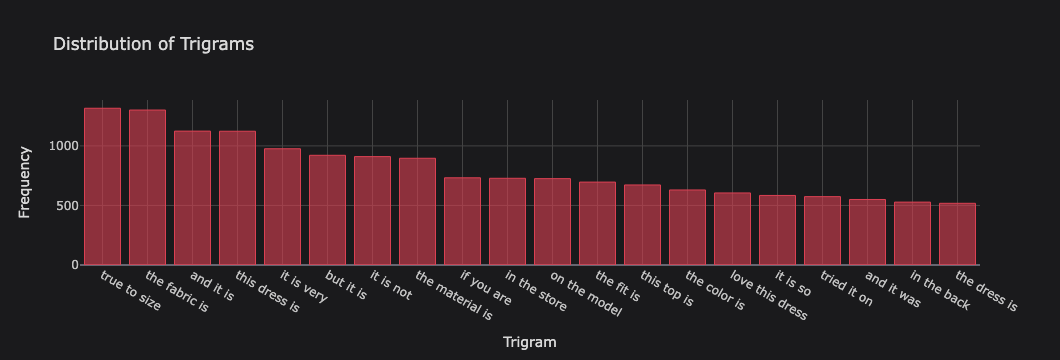

In [223]:
df1 = df1.set_index('Trigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Trigram', 
    yTitle='Frequency', 
    title='Distribution of Trigrams')

## DISTRIBUTION OF UNIGRAM, BIGRAM AND DIAGRAM WITHOUT STOPWORDS

#### Unigram

In [239]:
def get_top_words(x, n):
  vec = CountVectorizer(ngram_range=(1, 1), stop_words='english').fit(x) #added stop_words='english'
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n]

In [241]:
get_top_words(x, 3)

[('list', 2)]

In [243]:
words = get_top_words(df['Review Text'], 20)
words

[('dress', 10567),
 ('love', 8944),
 ('size', 8770),
 ('fit', 7322),
 ('like', 7148),
 ('wear', 6433),
 ('great', 6113),
 ('just', 5604),
 ('fabric', 4797),
 ('small', 4726),
 ('color', 4604),
 ('look', 4039),
 ('really', 3924),
 ('ordered', 3850),
 ('little', 3773),
 ('perfect', 3772),
 ('flattering', 3518),
 ('did', 3448),
 ('soft', 3336),
 ('comfortable', 3058)]

In [245]:
df1 = pd.DataFrame(words, columns=['Unigram', 'Frequency'])
df1.head()

,Unigram,Frequency
0,dress,10567
1,love,8944
2,size,8770
3,fit,7322
4,like,7148


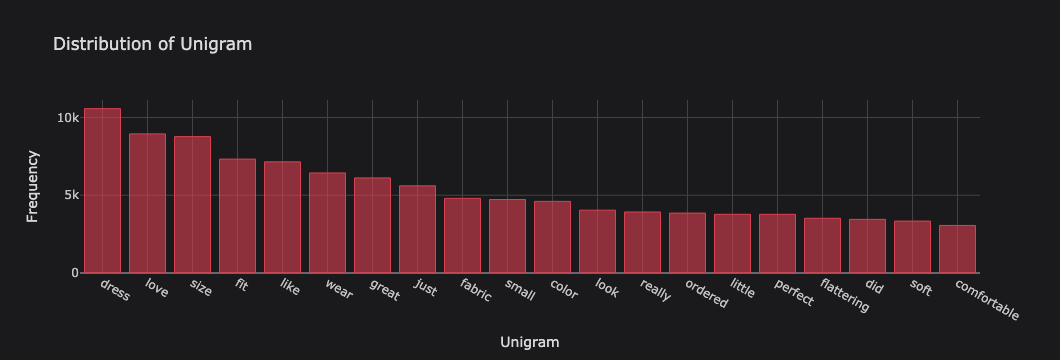

In [247]:
df1 = df1.set_index('Unigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Unigram', 
    yTitle='Frequency', 
    title='Distribution of Unigram')

#### Bigram

In [251]:
def get_top_words(x, n):
  vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(x) #added stop_words='english'
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n]

In [253]:
get_top_words(x, 3)

[('list list', 1)]

In [255]:
words = get_top_words(df['Review Text'], 20)
words

[('true size', 1347),
 ('love dress', 766),
 ('usually wear', 694),
 ('looks great', 620),
 ('fit perfectly', 609),
 ('size small', 540),
 ('fits perfectly', 489),
 ('usual size', 479),
 ('just right', 434),
 ('look like', 426),
 ('ordered size', 375),
 ('love love', 374),
 ('looks like', 373),
 ('runs large', 367),
 ('super cute', 363),
 ('highly recommend', 363),
 ('wear size', 361),
 ('fabric soft', 355),
 ('feel like', 349),
 ('fit great', 348)]

In [256]:
df1 = pd.DataFrame(words, columns=['Bigram', 'Frequency'])
df1.head()

,Bigram,Frequency
0,true size,1347
1,love dress,766
2,usually wear,694
3,looks great,620
4,fit perfectly,609


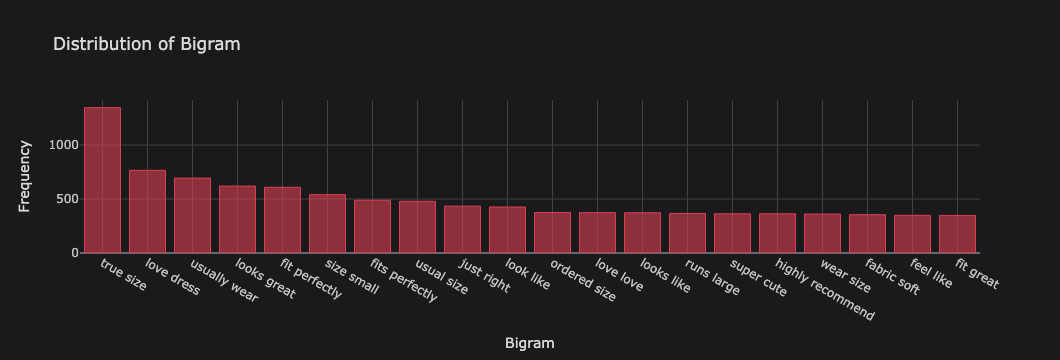

In [257]:
df1 = df1.set_index('Bigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Bigram', 
    yTitle='Frequency', 
    title='Distribution of Bigram')

#### Trigram

In [282]:
def get_top_words(x, n):
  vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(x) #added stop_words='english'
  bow = vec.transform(x)
  sum_words = bow.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
  return words_freq[:n]

In [286]:
#get_top_words(x, 3)

In [276]:
words = get_top_words(df['Review Text'], 20)
words

[('dress', 10567),
 ('love', 8944),
 ('size', 8770),
 ('fit', 7322),
 ('like', 7148),
 ('wear', 6433),
 ('great', 6113),
 ('just', 5604),
 ('fabric', 4797),
 ('small', 4726),
 ('color', 4604),
 ('look', 4039),
 ('really', 3924),
 ('ordered', 3850),
 ('little', 3773),
 ('perfect', 3772),
 ('flattering', 3518),
 ('did', 3448),
 ('soft', 3336),
 ('comfortable', 3058)]

In [278]:
df1 = pd.DataFrame(words, columns=['Trigram', 'Frequency'])
df1.head()

,Trigram,Frequency
0,dress,10567
1,love,8944
2,size,8770
3,fit,7322
4,like,7148


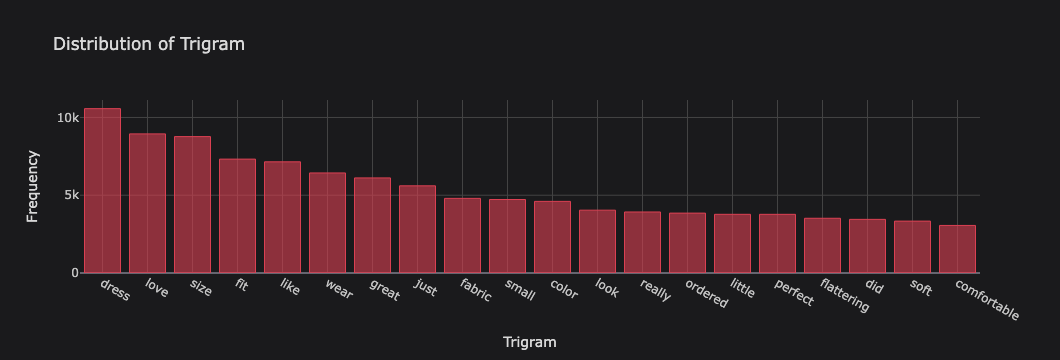

In [280]:
df1 = df1.set_index('Trigram')

df1.iplot(
    kind='bar', 
    colors='red', 
    xTitle='Trigram', 
    yTitle='Frequency', 
    title='Distribution of Trigram')

## DISTRIBUTION OF TOP 20 `Parts-of-Speech POS` tags

In [291]:
#!pip install nltk

In [295]:
import nltk
import textblob

In [297]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('tagsets')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ridvanyigit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ridvanyigit/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ridvanyigit/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package tagsets to
[nltk_data]     /Users/ridvanyigit/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.


True

In [299]:
print(str(df['Review Text'].head()))

0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it is sooo pretty.  i happen...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it is fun, f...
4    This shirt is very flattering to all due to th...
Name: Review Text, dtype: object


In [301]:
blob = TextBlob(str(df['Review Text']))

In [305]:
pos_df = pd.DataFrame(blob.tags, columns=['words', 'pos'])
pos_df.head()

,words,pos
0,0,CD
1,Absolutely,RB
2,wonderful,JJ
3,silky,NN
4,and,CC


In [307]:
pos_df = pos_df['pos'].value_counts()
pos_df

pos
NN     23
DT     15
JJ     13
CD     11
PRP     8
RB      6
VBZ     5
VBP     5
IN      5
CC      4
NNP     4
VBD     4
TO      3
NNS     2
VB      2
PDT     1
Name: count, dtype: int64

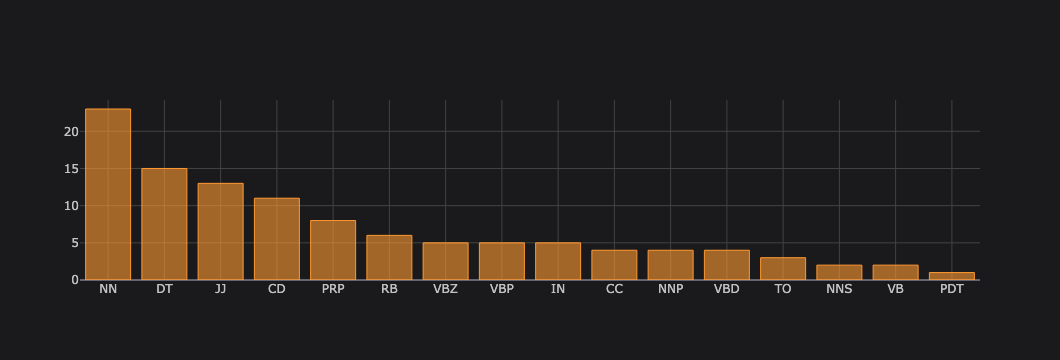

In [309]:
pos_df.iplot(kind='bar')

## Bivariate Analysis

In [312]:
df.head(2)

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len,word_count,avg_word_len
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53,8,5.750000
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583,306,65,3.646154


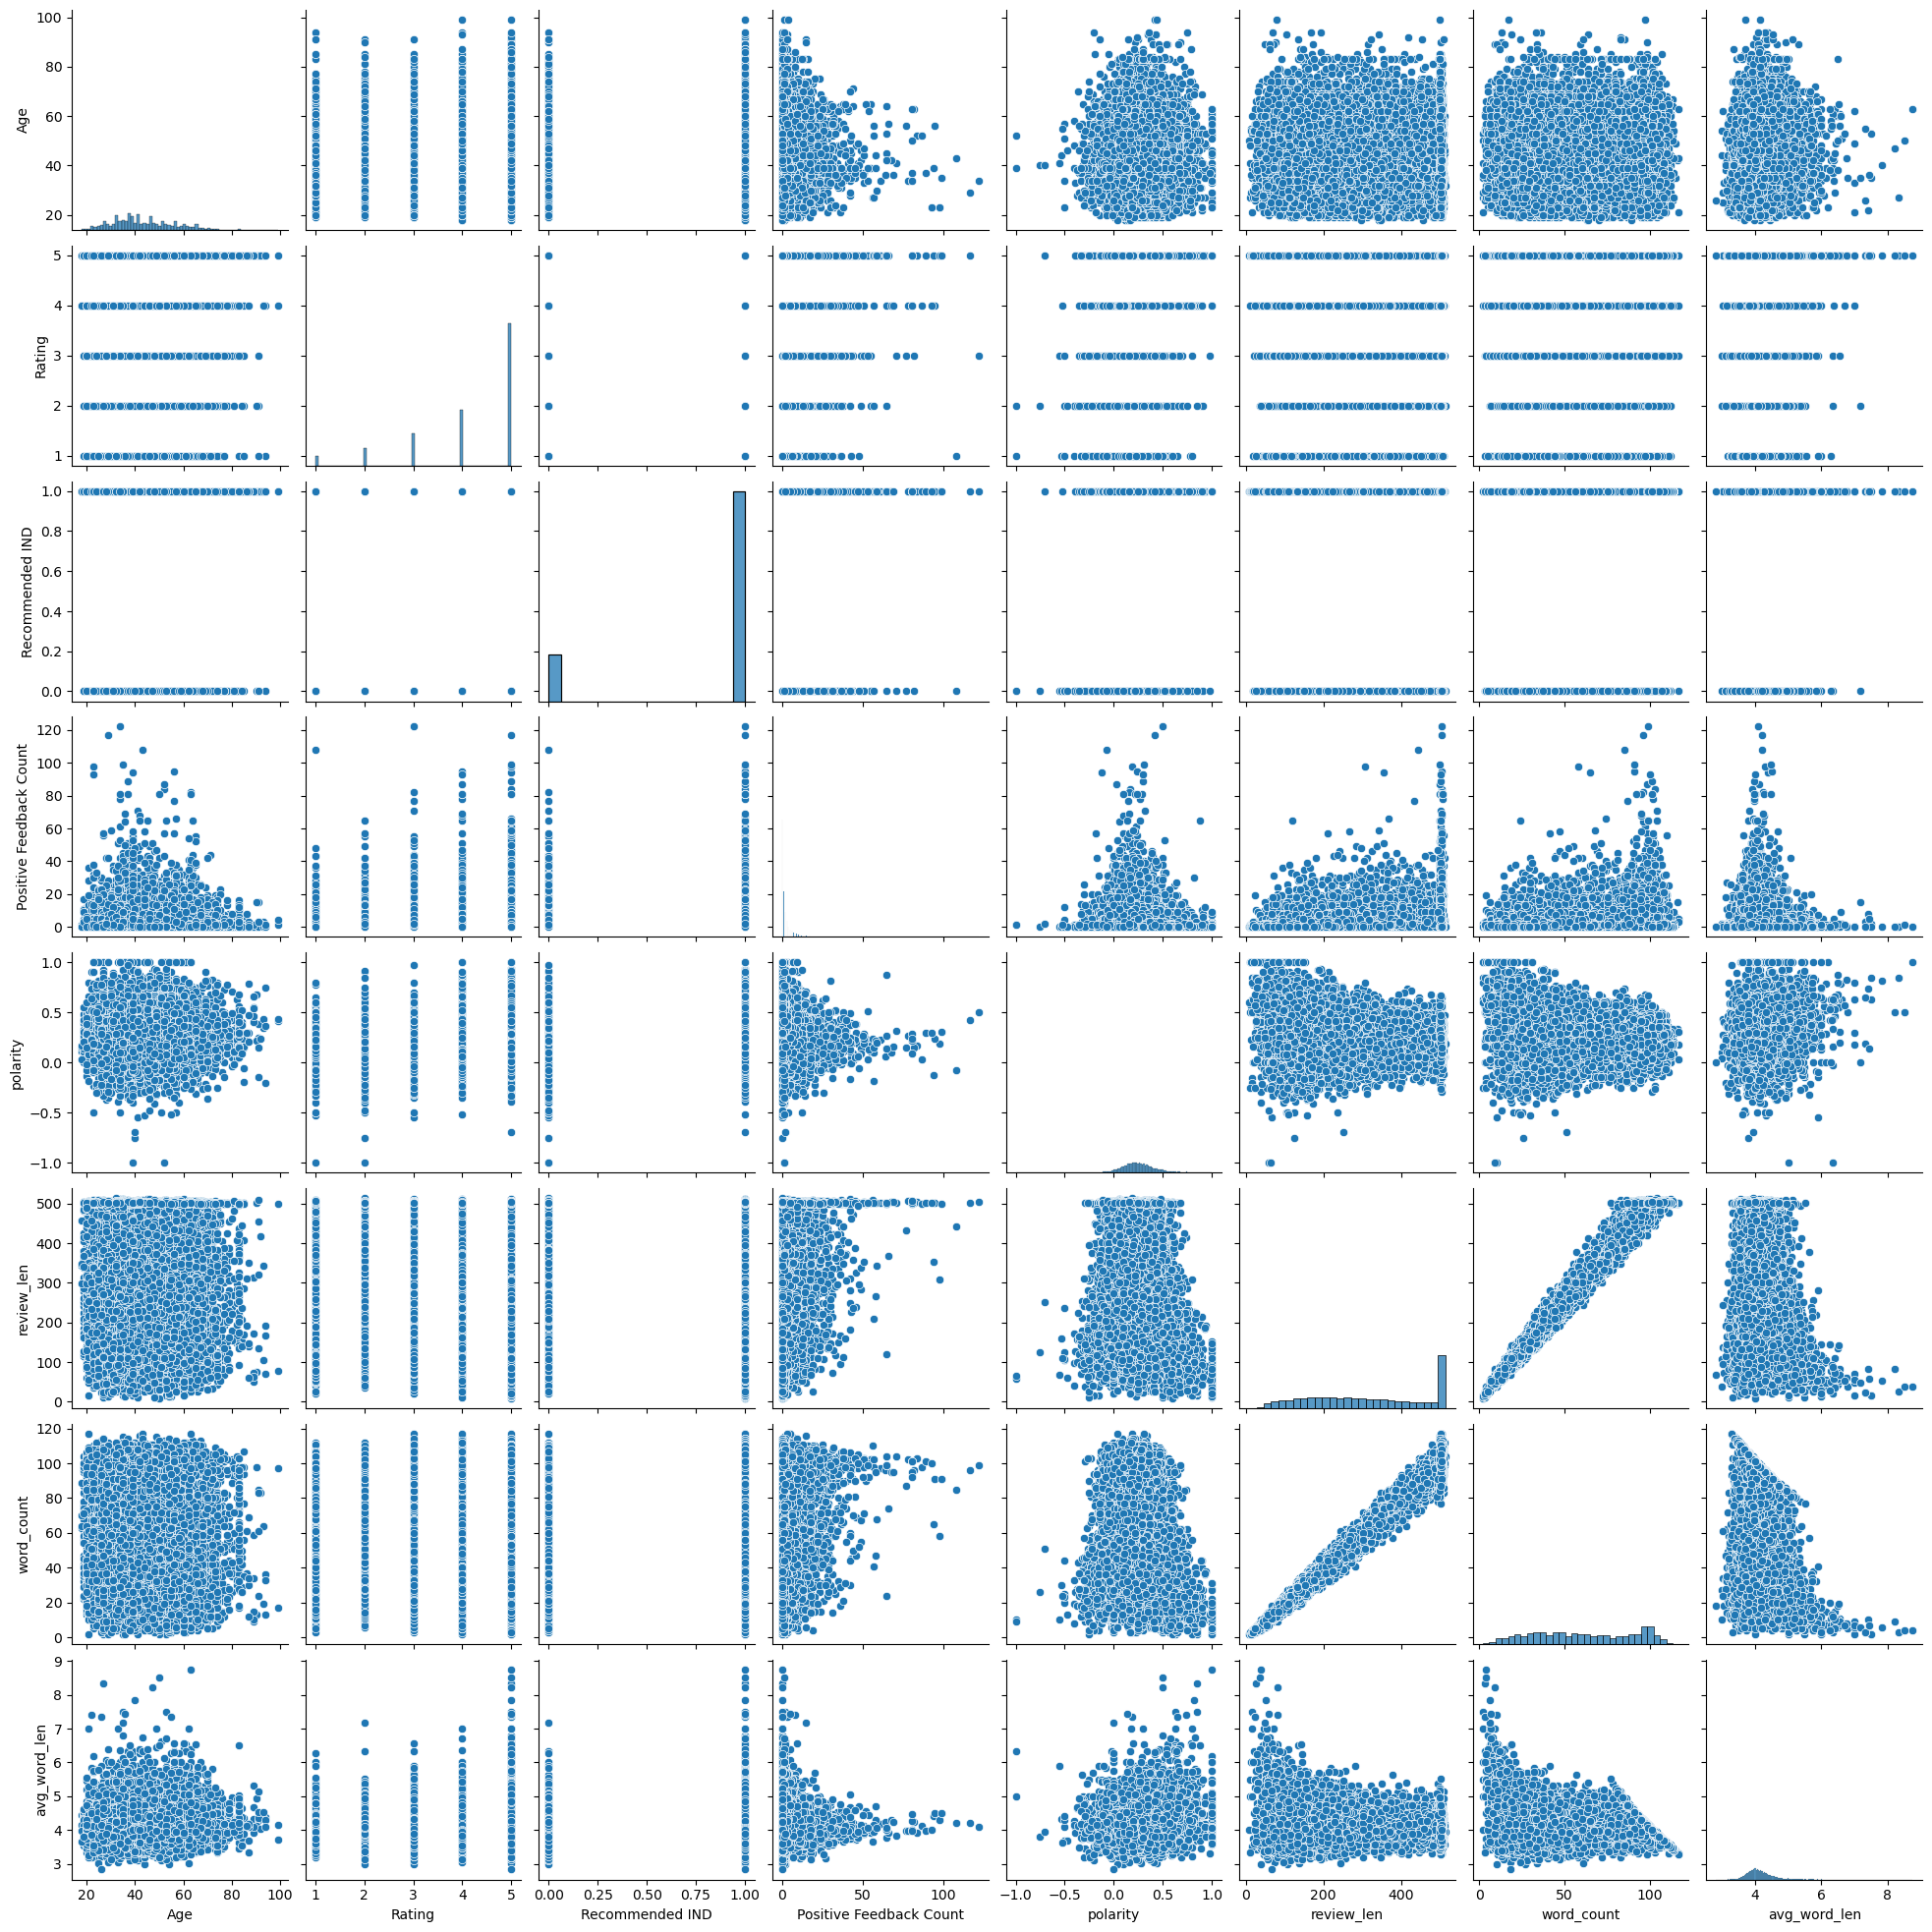

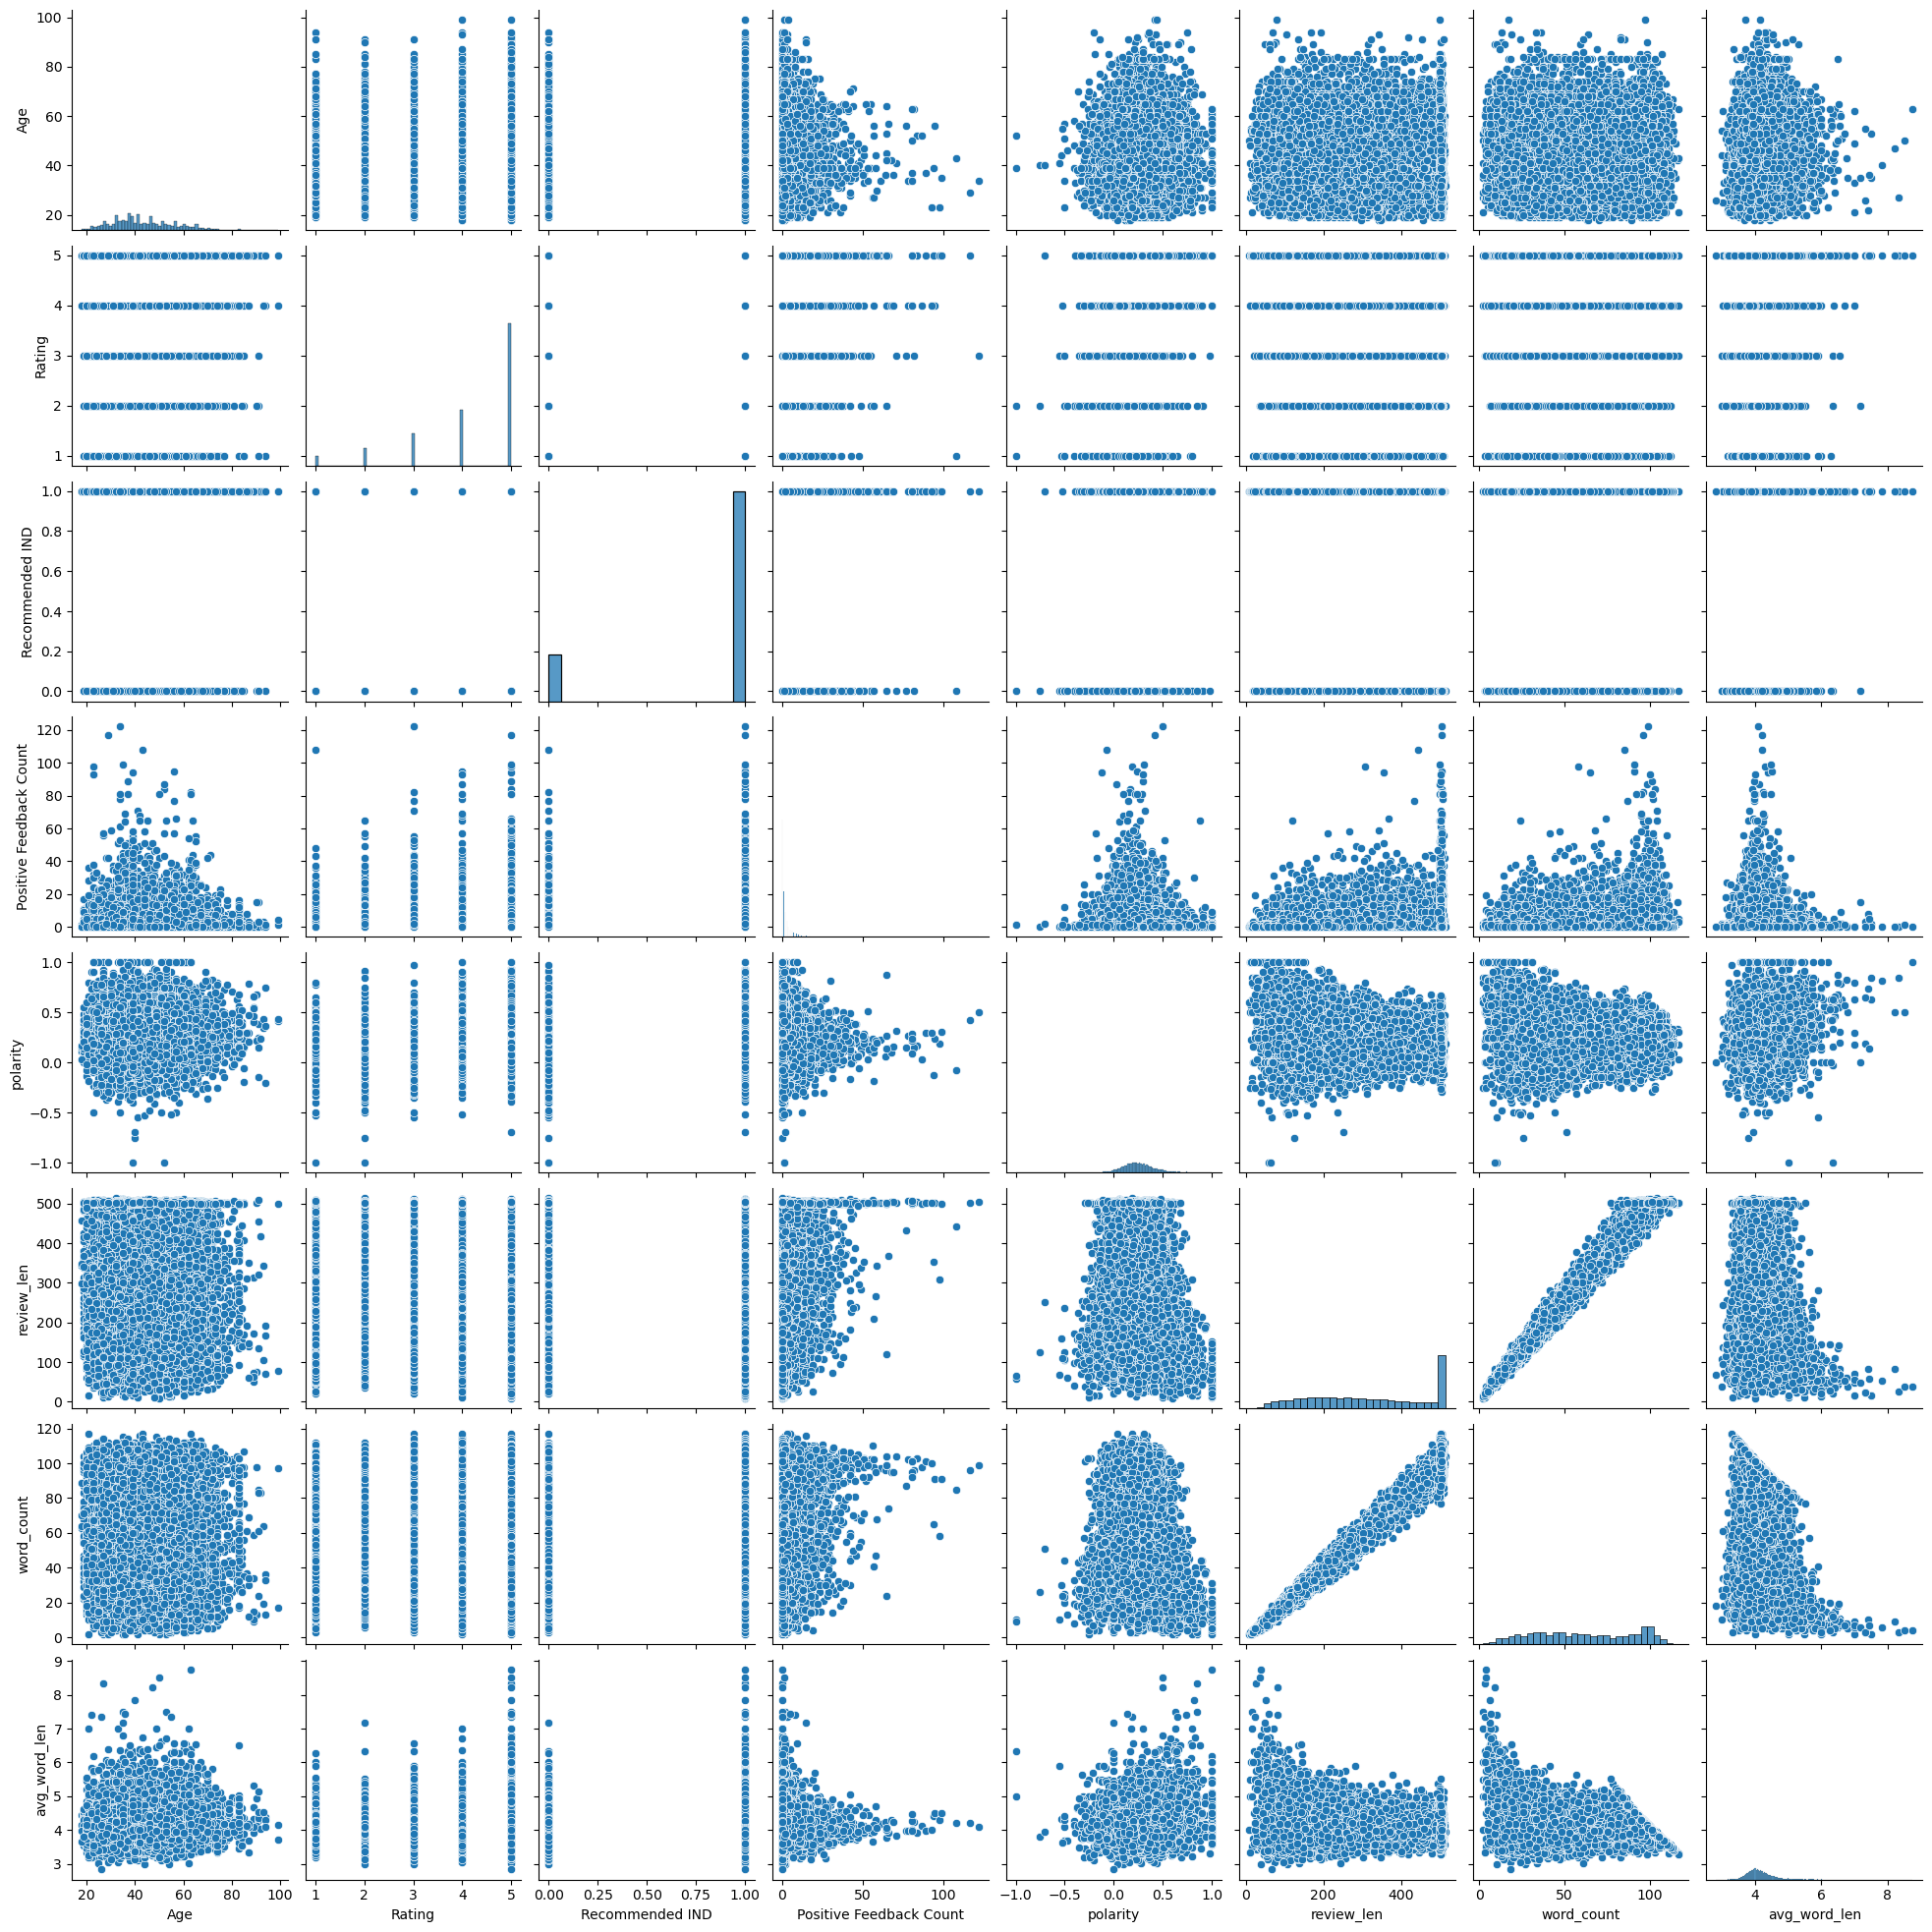

In [316]:
sns.pairplot(df)
plt.show()

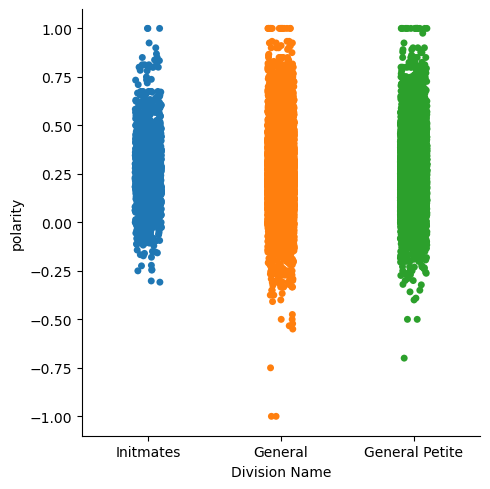

In [328]:
sns.catplot(x='Division Name', y='polarity', hue='Division Name', data=df)
plt.show()

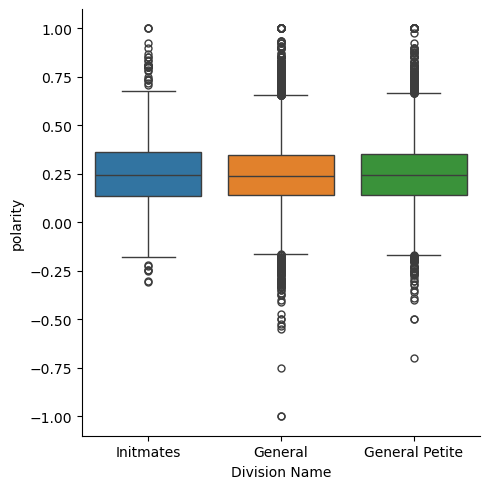

In [330]:
sns.catplot(x='Division Name', y='polarity', kind='box', hue='Division Name', data=df)
plt.show()

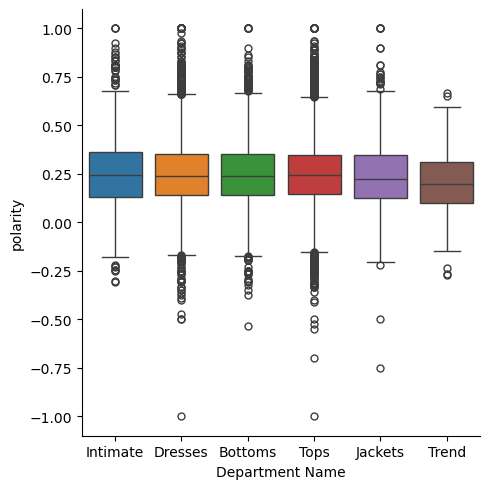

In [342]:
sns.catplot(x='Department Name', y='polarity', kind='box', hue='Department Name', data=df)
plt.show()

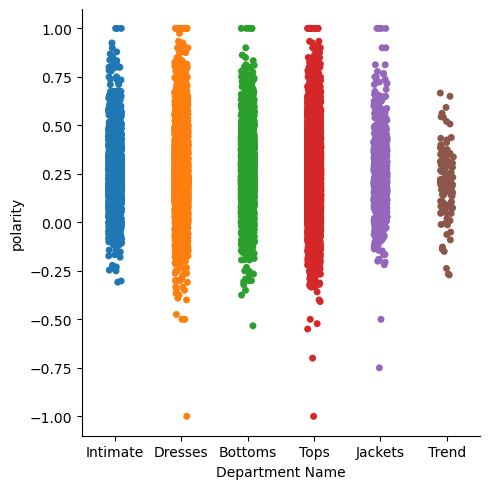

In [334]:
sns.catplot(x='Department Name', y='polarity', hue='Department Name', data=df)
plt.show()

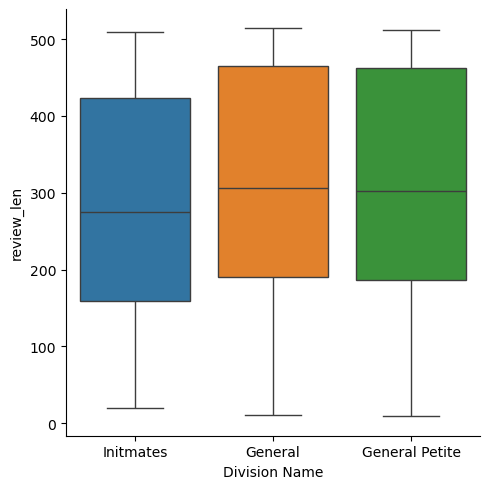

In [348]:
sns.catplot(x='Division Name', y='review_len', kind='box', hue='Division Name', data=df)
plt.show() 

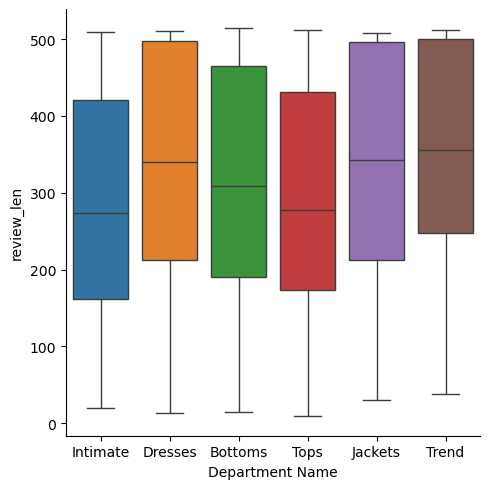

In [350]:
sns.catplot(x='Department Name', y='review_len', kind='box', hue='Department Name', data=df)
plt.show() 

In [370]:
import plotly.express as px
import plotly.graph_objects as go

In [372]:
x1 = df[df['Recommended IND']==1]
x1.head()

,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,polarity,review_len,word_count,avg_word_len
0,33,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.633333,53,8,5.750000
1,34,Love this dress! it is sooo pretty. i happen...,5,1,4,General,Dresses,Dresses,0.339583,306,65,3.646154
3,50,"I love, love, love this jumpsuit. it is fun, f...",5,1,0,General Petite,Bottoms,Pants,0.550000,125,23,4.478261
4,47,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.512891,192,36,4.361111
6,39,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,0.133750,496,101,3.920792


In [409]:
x0 = df[df['Recommended IND']==0]['polarity']
x1 = df[df['Recommended IND']==1]['polarity']
x1.head() 

0    0.633333
1    0.339583
3    0.550000
4    0.512891
6    0.133750
Name: polarity, dtype: float64

In [411]:
trace0 = go.Histogram(x=x0, name='Not Recommended', opacity=0.8)
trace1 = go.Histogram(x=x1, name='Recommended', opacity=0.8)

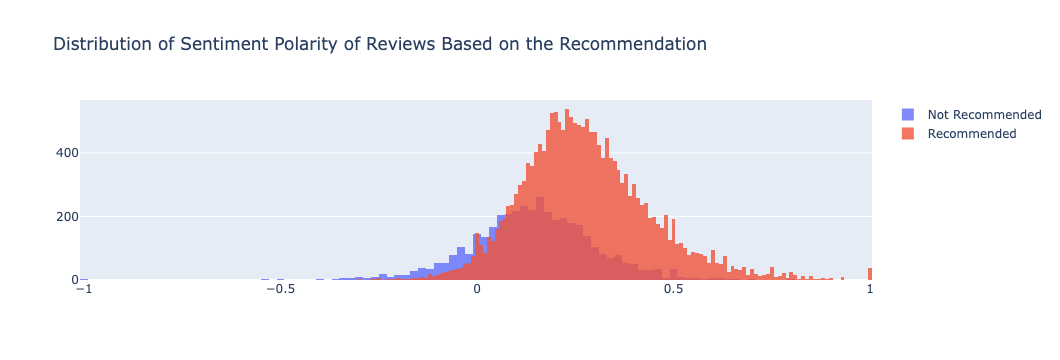

In [413]:
data = [trace0, trace1]
layout = go.Layout(barmode='overlay', title='Distribution of Sentiment Polarity of Reviews Based on the Recommendation')
fig = go.Figure(data=data, layout=layout)
iplot(fig)

## DISTRIBUTION OF RATING BASED ON THE RECOMMENDATION

In [416]:
x0 = df[df['Recommended IND']==0]['Rating']
x1 = df[df['Recommended IND']==1]['Rating']
x1.head() 

0    4
1    5
3    5
4    5
6    5
Name: Rating, dtype: int64

In [418]:
trace0 = go.Histogram(x=x0, name='Not Recommended', opacity=0.8)
trace1 = go.Histogram(x=x1, name='Recommended', opacity=0.8)

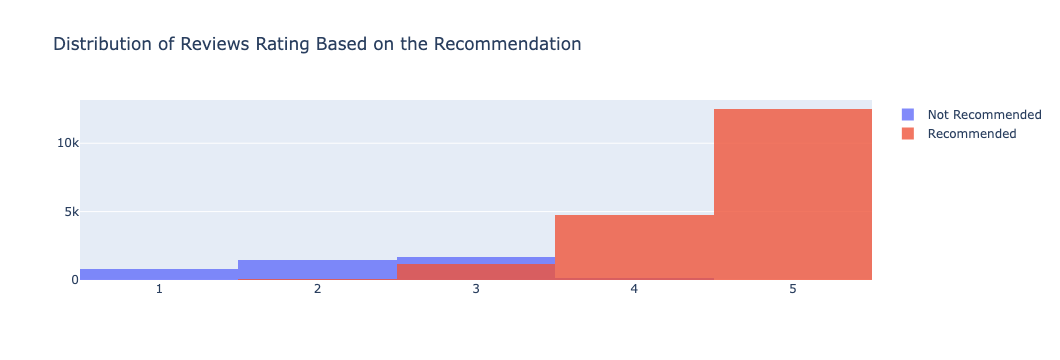

In [420]:
data = [trace0, trace1]
layout = go.Layout(barmode='overlay', title='Distribution of Reviews Rating Based on the Recommendation')
fig = go.Figure(data=data, layout=layout)
iplot(fig)

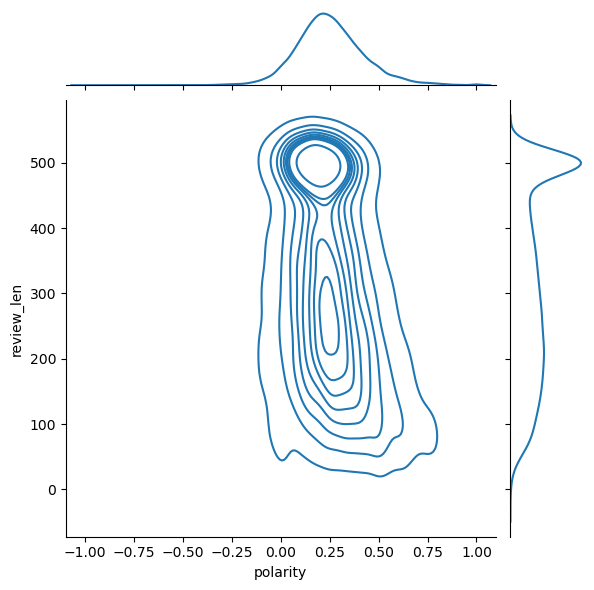

In [422]:
sns.jointplot(x='polarity', y='review_len', kind='kde', data=df)
plt.show()

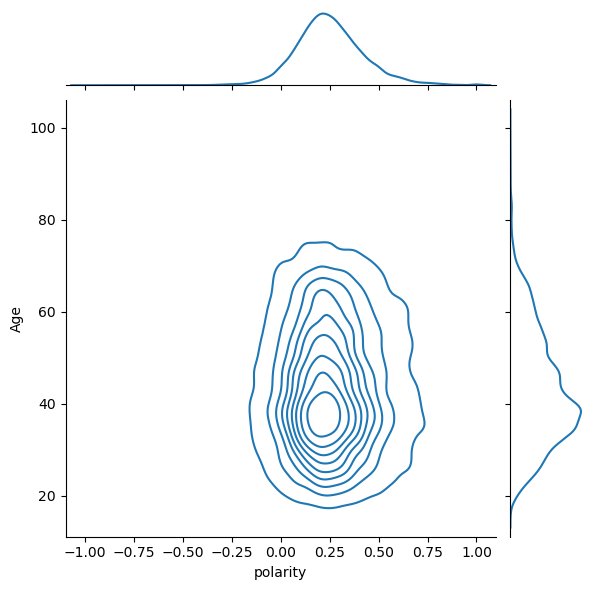

In [424]:
sns.jointplot(x='polarity', y='Age', kind='kde', data=df)
plt.show()